In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("idx_stock_final_clean.csv", index_col=0, parse_dates=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1, 510)


,AADI,AALI,ABBA,ABDA,ABMM,ACES,ACRO,ACST,ADCP,ADES,...,LAPD,LCGP,LCKM,LEAD,LFLO,LIFE,LINK,LION,LIVE,LMAS
date,,,,,,,,,,,,,,,,,,,,,
2025-04-09,5750.0,5275.0,16.0,3400.0,2830.0,462.0,53.0,64.0,50.0,9500.0,...,17.0,114.0,230.0,70.0,113.0,6125.0,2000.0,316.0,151.0,50.0


In [18]:
df = df.dropna(axis=1, thresh=int(0.3 * len(df)))

df = df.fillna(method='ffill').fillna(method='bfill')

print("After aggressive cleaning:", df.shape)

After aggressive cleaning: (1, 510)


C:\Users\ivanf\AppData\Local\Temp\ipykernel_17136\2904105002.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


In [8]:
print("Total Stocks:", len(df.columns))
print("Total Dates:", len(df.index))

Total Stocks: 510
Total Dates: 1


In [15]:
print(df.head())
print(df.describe())
print(df.isna().sum().sum())

              AADI    AALI  ABBA    ABDA    ABMM   ACES  ACRO  ACST  ADCP  \
date                                                                        
2025-04-09  5750.0  5275.0  16.0  3400.0  2830.0  462.0  53.0  64.0  50.0   

              ADES  ...  LAPD   LCGP   LCKM  LEAD   LFLO    LIFE    LINK  \
date                ...                                                    
2025-04-09  9500.0  ...  17.0  114.0  230.0  70.0  113.0  6125.0  2000.0   

             LION   LIVE  LMAS  
date                            
2025-04-09  316.0  151.0  50.0  

[1 rows x 510 columns]
         AADI    AALI  ABBA    ABDA    ABMM   ACES  ACRO  ACST  ADCP    ADES  \
count     1.0     1.0   1.0     1.0     1.0    1.0   1.0   1.0   1.0     1.0   
mean   5750.0  5275.0  16.0  3400.0  2830.0  462.0  53.0  64.0  50.0  9500.0   
std       NaN     NaN   NaN     NaN     NaN    NaN   NaN   NaN   NaN     NaN   
min    5750.0  5275.0  16.0  3400.0  2830.0  462.0  53.0  64.0  50.0  9500.0   
25%    5750.0  5

In [16]:
print(idx_index.head())
print(idx_index.isna().sum())

date
2025-04-09    1413.701961
dtype: float64
0


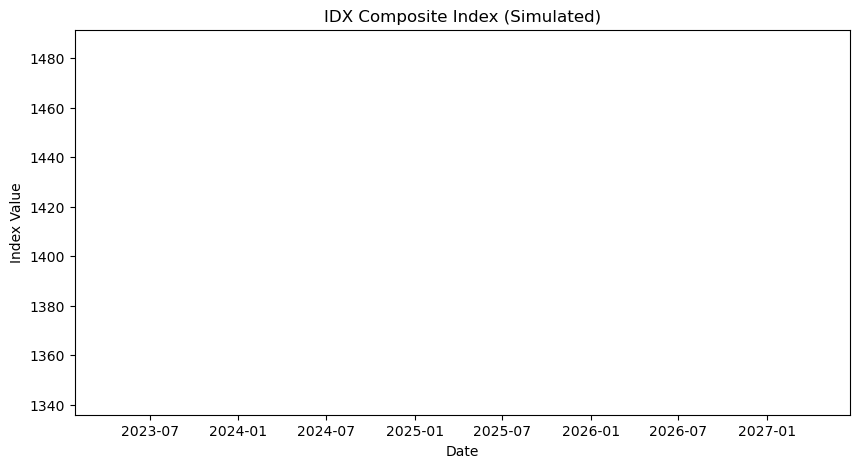

In [17]:
idx_index = df.mean(axis=1)

idx_index = idx_index.dropna()

plt.figure(figsize=(10,5))
plt.plot(idx_index)

plt.title("IDX Composite Index (Simulated)")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.show()

In [19]:
print(df.shape)
print(df.head())

(1, 510)
              AADI    AALI  ABBA    ABDA    ABMM   ACES  ACRO  ACST  ADCP  \
date                                                                        
2025-04-09  5750.0  5275.0  16.0  3400.0  2830.0  462.0  53.0  64.0  50.0   

              ADES  ...  LAPD   LCGP   LCKM  LEAD   LFLO    LIFE    LINK  \
date                ...                                                    
2025-04-09  9500.0  ...  17.0  114.0  230.0  70.0  113.0  6125.0  2000.0   

             LION   LIVE  LMAS  
date                            
2025-04-09  316.0  151.0  50.0  

[1 rows x 510 columns]


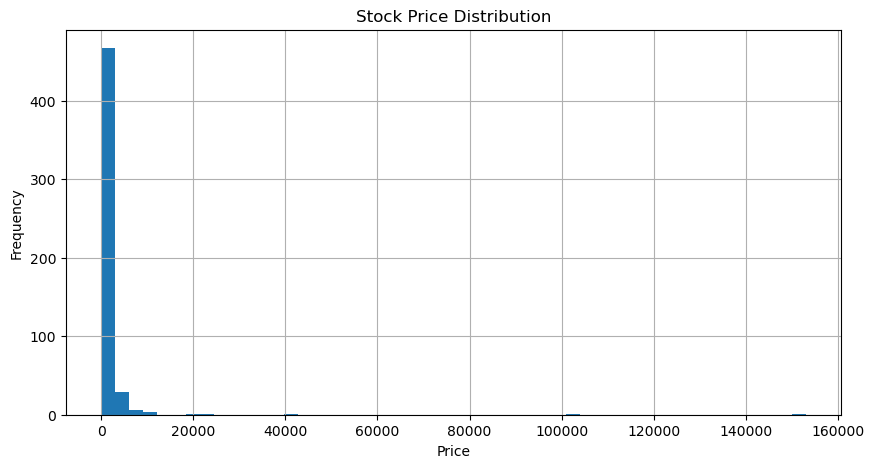

In [20]:
prices = df.iloc[0]

plt.figure(figsize=(10,5))
prices.hist(bins=50)
plt.title("Stock Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

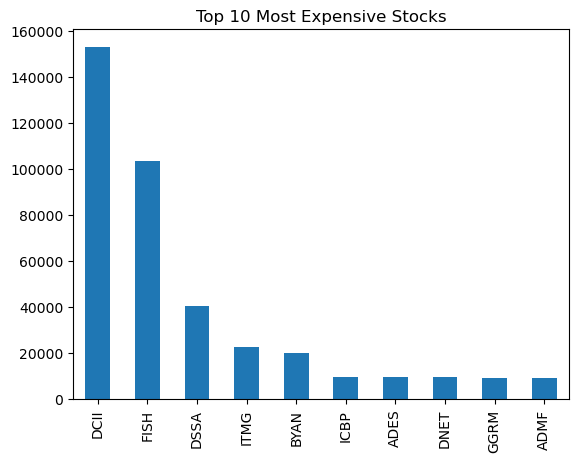

In [21]:
top_price = prices.sort_values(ascending=False).head(10)

top_price.plot(kind='bar')
plt.title("Top 10 Most Expensive Stocks")
plt.show()

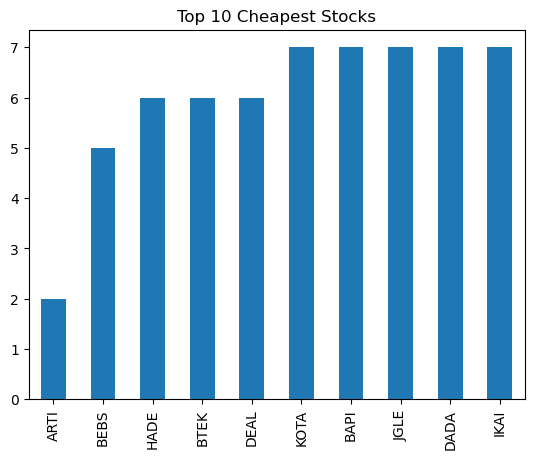

In [22]:
low_price = prices.sort_values().head(10)

low_price.plot(kind='bar')
plt.title("Top 10 Cheapest Stocks")
plt.show()

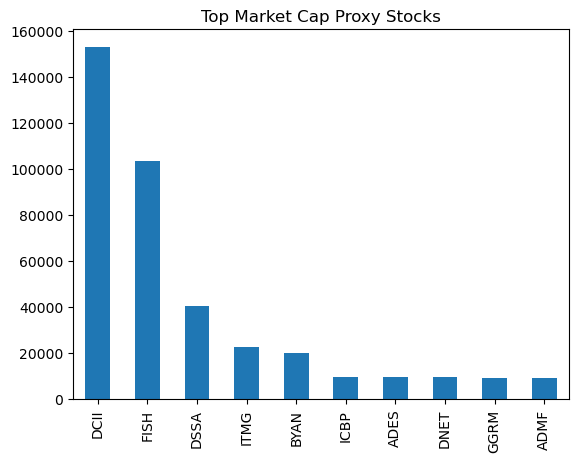

In [23]:
market_cap = prices.sort_values(ascending=False)

market_cap.head(10).plot(kind='bar')
plt.title("Top Market Cap Proxy Stocks")
plt.show()

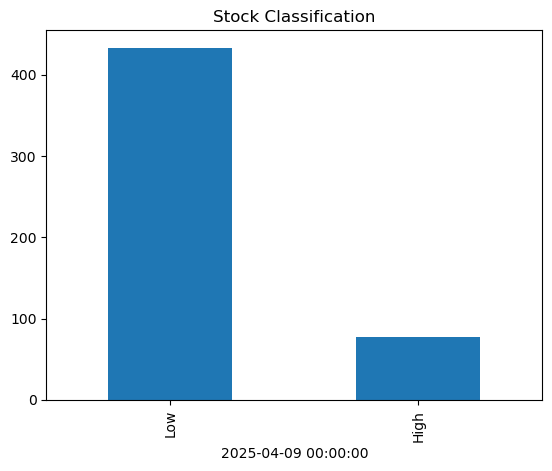

In [24]:
mean_price = prices.mean()

classification = prices.apply(lambda x: "High" if x > mean_price else "Low")

classification.value_counts().plot(kind='bar')
plt.title("Stock Classification")
plt.show()

In [25]:
print("Mean price:", prices.mean())
print("Max price:", prices.max())
print("Min price:", prices.min())

Mean price: 1413.7019607843138
Max price: 153000.0
Min price: 2.0


### 📊 Insights (Revised)

1. The dataset represents a snapshot of the Indonesian stock market on a single date.
2. Stock prices vary significantly across companies.
3. A small number of stocks dominate in price (high-value stocks).
4. Many stocks are clustered in lower price ranges.
5. This indicates market inequality in stock valuation.

### 📌 Conclusion

Due to API limitations, the dataset contains only one time snapshot. Therefore, analysis focuses on cross-sectional insights rather than time-series trends.